In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

## Overview

This notebook explores **feature importance** as a tool for feature selection in classification tasks.

**Key questions:**
- Which features actually matter for predicting the class label?
- Can we identify and remove irrelevant features without hurting model accuracy?
- Do different models agree on which features are important?

We work through two phases:
1. **Visual exploration** — a simple 2-feature dataset to build intuition about what feature importance means
2. **Modeling experiment** — a 50-feature dataset where most features are noise, to see feature selection in action

# Visual analysis of feature importance

## Create data

We generate a synthetic 2-class, 2-feature dataset. Several options are available via the `choice` variable:

| `choice` | Generator | Shape |
|----------|-----------|-------|
| 0 | `make_blobs` | Two Gaussian blobs |
| 1 | `make_classification` | Overlapping clusters |
| 2 | `make_moons` | Two crescent shapes |
| 3 | `make_circles` | Concentric rings |

Starting with `choice = 0` (blobs) gives us a cleanly separable dataset. The 2D view lets us visually confirm which features are useful — but in real problems we have many more features and can't visualize this directly. That's where feature importance scores come in.

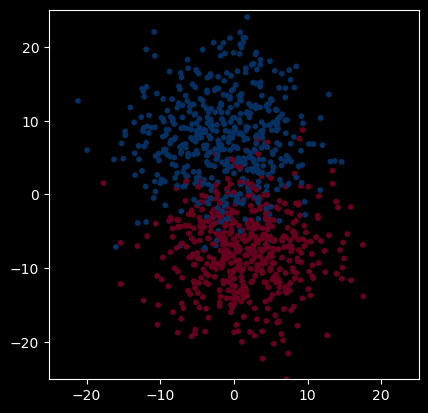

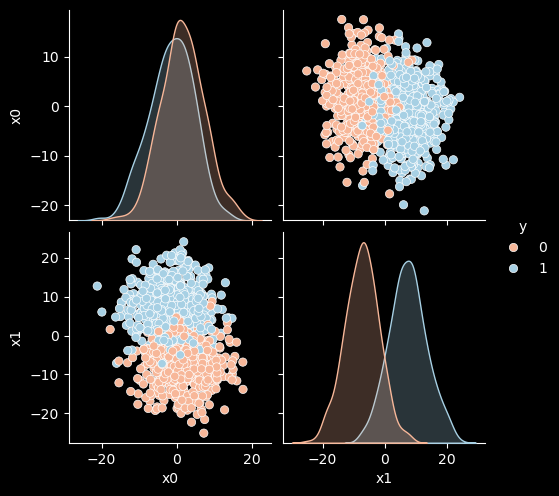

In [16]:
from sklearn.datasets import make_classification, make_blobs, make_moons, make_circles

n_samples = 1000

choice = 0

if   choice == 0:
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=2,
        centers=2,
        cluster_std=6,
        random_state=10
    )
elif choice == 1:
    X, y = make_classification(
        n_samples=n_samples,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        n_classes=2,
        #random_state=41
    )
elif choice == 2:
    X, y = make_moons(
        n_samples=n_samples,
        noise=0.2,
        random_state=42
    )
elif choice == 3:
    X, y = make_circles(
        n_samples=n_samples,
        noise=0.1,
        factor=0.5,
        random_state=42
    )
# end

X = X - X.mean(axis=0)

MAX = np.max(np.abs(X))

plt.style.use('dark_background')

plt.scatter(X[:,0], X[:,1], c=y, s=10, cmap="RdBu");
plt.xlim(-MAX,MAX)
plt.ylim(-MAX,MAX)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

The scatter plot above shows all samples colored by class. The pairplot shows the marginal and joint distributions of each feature split by class.

**What to look for:** If the two classes are well-separated along a feature's axis in the pairplot diagonal, that feature is informative. If the distributions overlap completely, the feature adds little predictive value.

In [17]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Fit models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

rf.fit(X, y)
gb.fit(X, y)
dt.fit(X, y)

# Extract feature importances
rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_
dt_importance = dt.feature_importances_

### Feature importance scores

Each tree-based model produces a `feature_importances_` array — one score per feature that sums to 1.0 across all features. The score reflects how much that feature reduced impurity (Gini or entropy) on average across all splits in all trees.

- Higher score → feature appears near the top of trees and creates clean splits
- Score near 0 → feature was rarely used, or its splits didn't help much

The violin plots below show the class-conditional distribution of each feature (how differently the two classes are distributed along that feature's axis), followed by bar charts comparing importance scores across the three models.

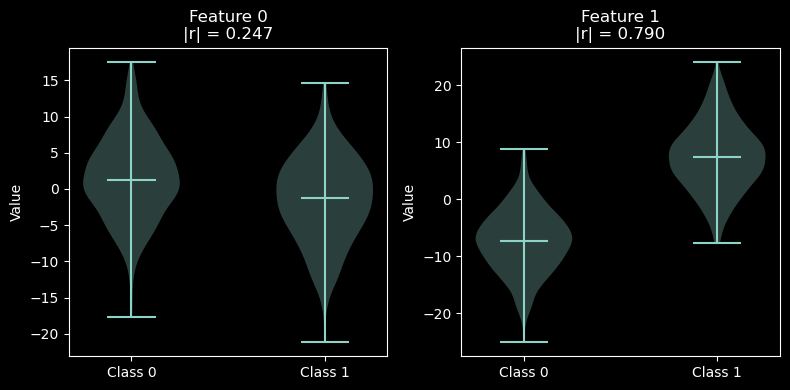

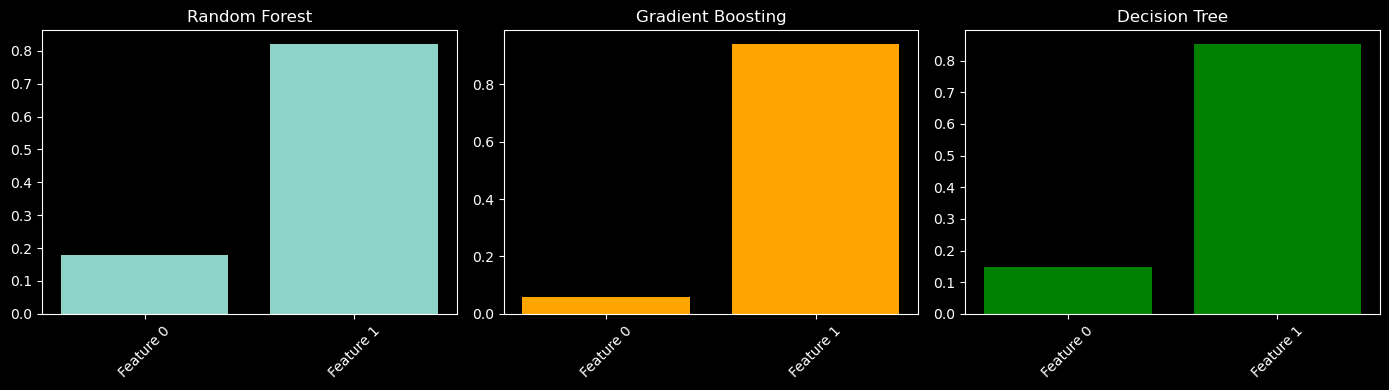

In [18]:
n_feat = X.shape[1]

# Violin plots: feature distribution by class
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4))
if n_feat == 1:
    axes = [axes]

for i in range(n_feat):
    r = np.corrcoef(X[:, i], y)[0, 1]
    abs_r = abs(r)

    parts = axes[i].violinplot(
        [X[y == 0, i], X[y == 1, i]],
        positions=[0, 1],
        showmedians=True
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Class 0', 'Class 1'])
    axes[i].set_title(f'Feature {i}\n|r| = {abs_r:.3f}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

###################

# Plot feature importances
feature_names = [f"Feature {i}" for i in range(n_feat)]
x = np.arange(n_feat)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(x, rf_importance)
plt.xticks(x, feature_names, rotation=45)
plt.title("Random Forest")

plt.subplot(1, 3, 2)
plt.bar(x, gb_importance, color='orange')
plt.xticks(x, feature_names, rotation=45)
plt.title("Gradient Boosting")

plt.subplot(1, 3, 3)
plt.bar(x, dt_importance, color='green')
plt.xticks(x, feature_names, rotation=45)
plt.title("Decision Tree")

plt.tight_layout()
plt.show()

**Interpreting the violin plots:** A feature is informative when the two class distributions have clearly different medians or little overlap. The `|r|` value is the absolute point-biserial correlation — higher means a stronger linear relationship with the class label.

**Interpreting the bar charts:** All three models should assign similar importance scores for this simple 2-feature dataset. In the next section we scale up to 50 features, where the models' rankings will diverge more and the value of selection becomes clearer.

# Modeling

**Can we remove bad features without harming accuracy?**

In real-world datasets we often have dozens or hundreds of features. Many are:
- **Irrelevant** — no relationship to the target at all
- **Redundant** — correlated with other features, adding little new information

Feature importance scores give us a ranking. The strategy here:
1. Train a classifier on all features and extract importances
2. Sort features from most to least important
3. Incrementally add features (starting from the most important) and measure test accuracy
4. Observe whether accuracy peaks *before* using all features — indicating the remaining ones are noise

## Create data

We generate a higher-dimensional dataset with **50 features**, but only a fraction are actually informative:

| Feature type | Count | Description |
|---|---|---|
| Informative | 10 | Directly related to the class label |
| Redundant | 5 | Linear combinations of the informative features |
| Noise | 35 | Pure random noise — no predictive value |

In a real problem you wouldn't know which features are which. The goal of feature importance is to recover that structure automatically.

In [19]:
from sklearn import datasets

n_feat = 50

X, y = datasets.make_classification(
    n_samples=700,
    n_features=n_feat,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

The dataset has 700 samples across 2 balanced classes. If feature importance is working correctly, we'd expect the 10 truly informative features to score highest, the 5 redundant features to score moderately, and the 35 noise features to score near zero.

In [20]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2
)

We use an 80/20 train/test split with `stratify=y` to ensure both splits maintain the same class balance. All feature selection decisions are made using the training data only — the test set is reserved purely for unbiased evaluation.

## Get feature importances

We train all three classifiers on the **full** feature set (all 50 features) and extract their `feature_importances_` arrays. Each model is depth-constrained (`max_depth`) to prevent overfitting during this importance-extraction step — we want a stable ranking, not a perfectly tuned model.

The output for each model is an array of 50 scores that sum to 1.0. We sort the feature indices from most to least important, giving us a ranked list to use for incremental feature selection.

In [21]:
# Train models
rf = RandomForestClassifier(n_estimators=100, max_depth=5)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=2)
dt = DecisionTreeClassifier(max_depth=5)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Get feature importances
rf_importance = rf.feature_importances_
gb_importance = gb.feature_importances_
dt_importance = dt.feature_importances_

# Argsort importances (from most to least important)
rf_sorted_indices = np.argsort(-rf_importance)
gb_sorted_indices = np.argsort(-gb_importance)
dt_sorted_indices = np.argsort(-dt_importance)

### Iterative feature selection

Now we use those importance rankings to run a controlled experiment:

- For each `k` from 1 to 50: select the **top k** features according to each model's ranking
- Refit the model using only those k features (on training data)
- Record train accuracy and test accuracy

This gives us a curve of **accuracy vs. number of features used**. If the model achieves peak test accuracy with, say, 12 features instead of 50, that tells us the remaining 38 features are noise that hurts (or at least doesn't help) generalization.

In [22]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Store accuracy scores
rf_train_acc = []
rf_test_acc = []
gb_train_acc = []
gb_test_acc = []
dt_train_acc = []
dt_test_acc = []

# Loop over top k features
for k in tqdm(range(1, n_feat + 1), ncols=50):
    # Random Forest
    rf.fit(X_train[:, rf_sorted_indices[:k]], y_train)
    rf_train_acc.append(accuracy_score(y_train, rf.predict(X_train[:, rf_sorted_indices[:k]])))
    rf_test_acc.append(accuracy_score(y_test, rf.predict(X_test[:, rf_sorted_indices[:k]])))

    # Gradient Boosting
    gb.fit(X_train[:, gb_sorted_indices[:k]], y_train)
    gb_train_acc.append(accuracy_score(y_train, gb.predict(X_train[:, gb_sorted_indices[:k]])))
    gb_test_acc.append(accuracy_score(y_test, gb.predict(X_test[:, gb_sorted_indices[:k]])))

    # Decision Tree
    dt.fit(X_train[:, dt_sorted_indices[:k]], y_train)
    dt_train_acc.append(accuracy_score(y_train, dt.predict(X_train[:, dt_sorted_indices[:k]])))
    dt_test_acc.append(accuracy_score(y_test, dt.predict(X_test[:, dt_sorted_indices[:k]])))

100%|█████████████| 50/50 [00:23<00:00,  2.15it/s]


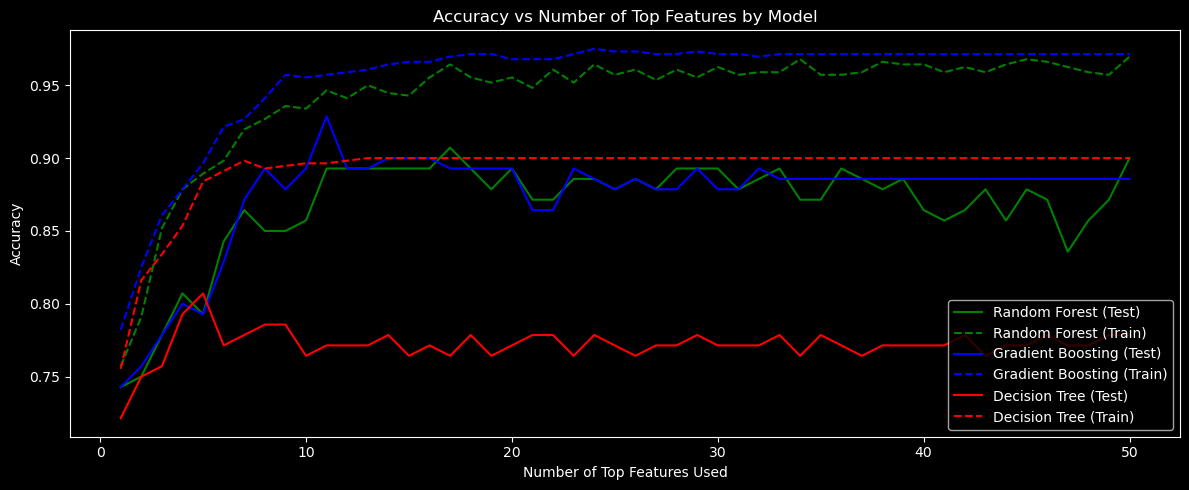

In [23]:
# Plotting
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(12, 5))

# Random Forest (green)
plt.plot(x, rf_test_acc, color='green', label='Random Forest (Test)')
plt.plot(x, rf_train_acc, color='green', linestyle='--', label='Random Forest (Train)')

# Gradient Boosting (blue)
plt.plot(x, gb_test_acc, color='blue', label='Gradient Boosting (Test)')
plt.plot(x, gb_train_acc, color='blue', linestyle='--', label='Gradient Boosting (Train)')

# Decision Tree (red)
plt.plot(x, dt_test_acc, color='red', label='Decision Tree (Test)')
plt.plot(x, dt_train_acc, color='red', linestyle='--', label='Decision Tree (Train)')

plt.xlabel("Number of Top Features Used")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Top Features by Model")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the curves:**

- **Test accuracy** (solid lines) rises quickly as the most important features are added, then levels off or may dip slightly
- **Train accuracy** (dashed lines) tends to be higher and may keep rising — the gap between train and test is the overfitting signal
- The point where **test accuracy peaks** is the optimal feature count for that model
- Features ranked beyond that peak are noise — including them doesn't help and can hurt generalization

Also notice that the three models don't necessarily agree on the optimal cutoff, or even on *which* features are most important. This is worth keeping in mind when using importance scores in practice.

> **Key takeaway:** Peak test accuracy is typically achieved with a *subset* of features, not all of them. This parallels L1/Lasso regularization — both are strategies for discouraging the model from relying on irrelevant features. Tree-based feature importance is a quick, model-native alternative that requires no tuning of a regularization hyperparameter.

## Using logistic regression on important features

So far we've re-evaluated the *same* tree models using fewer features. Here we ask a different question:

> If we use a tree's importance ranking to **select features**, then train a **logistic regression** on those features — how does it perform?

This is a common two-stage pipeline in practice:
1. Use a tree model to rank and select features (fast, interpretable)
2. Train a simpler linear model on the reduced feature set (faster inference, more explainable predictions)

Logistic regression can't produce tree-style feature importances, so it benefits from the pre-selection step. The experiment below shows whether tree-ranked features transfer well to a linear classifier.

In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize logistic regression model
lr = LogisticRegression(max_iter=1000)

# Store accuracy scores for Logistic Regression
lr_rf_train_acc = []
lr_rf_test_acc = []
lr_gb_train_acc = []
lr_gb_test_acc = []
lr_dt_train_acc = []
lr_dt_test_acc = []

# Loop over top k features
for k in tqdm(range(1, n_feat + 1), ncols=50):
    # LR on RF features
    lr.fit(X_train[:, rf_sorted_indices[:k]], y_train)
    lr_rf_train_acc.append(accuracy_score(y_train, lr.predict(X_train[:, rf_sorted_indices[:k]])))
    lr_rf_test_acc.append(accuracy_score(y_test, lr.predict(X_test[:, rf_sorted_indices[:k]])))

    # LR on GB features
    lr.fit(X_train[:, gb_sorted_indices[:k]], y_train)
    lr_gb_train_acc.append(accuracy_score(y_train, lr.predict(X_train[:, gb_sorted_indices[:k]])))
    lr_gb_test_acc.append(accuracy_score(y_test, lr.predict(X_test[:, gb_sorted_indices[:k]])))

    # LR on DT features
    lr.fit(X_train[:, dt_sorted_indices[:k]], y_train)
    lr_dt_train_acc.append(accuracy_score(y_train, lr.predict(X_train[:, dt_sorted_indices[:k]])))
    lr_dt_test_acc.append(accuracy_score(y_test, lr.predict(X_test[:, dt_sorted_indices[:k]])))

100%|█████████████| 50/50 [00:00<00:00, 64.36it/s]


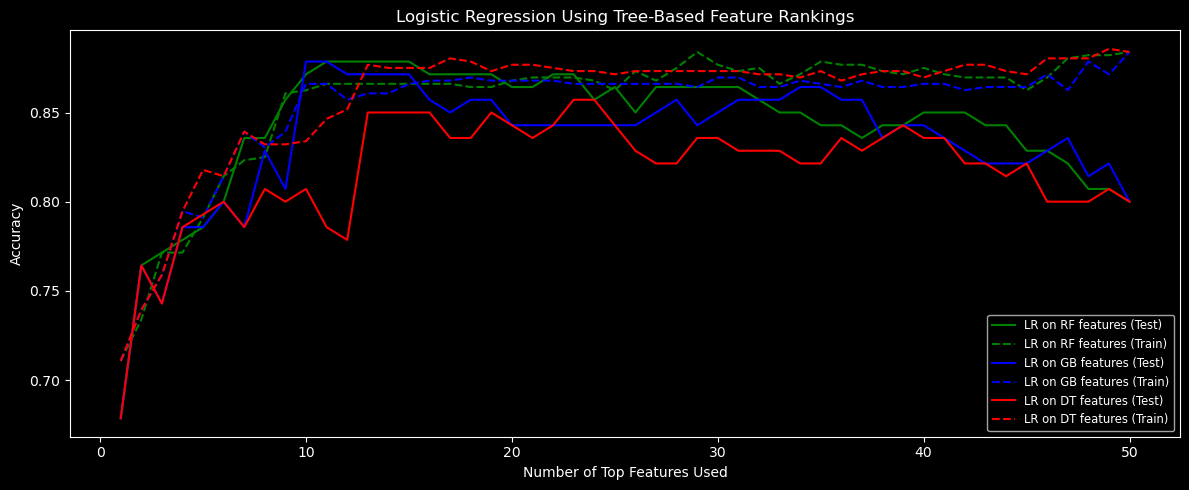

In [25]:
# Plotting Logistic Regression results using original color scheme
x = np.arange(1, n_feat + 1)
plt.figure(figsize=(12, 5))

# LR on RF-ranked features (green)
plt.plot(x, lr_rf_test_acc, color='green', label='LR on RF features (Test)')
plt.plot(x, lr_rf_train_acc, '--', color='green', label='LR on RF features (Train)')

# LR on GB-ranked features (blue)
plt.plot(x, lr_gb_test_acc, color='blue', label='LR on GB features (Test)')
plt.plot(x, lr_gb_train_acc, '--', color='blue', label='LR on GB features (Train)')

# LR on DT-ranked features (red)
plt.plot(x, lr_dt_test_acc, color='red', label='LR on DT features (Test)')
plt.plot(x, lr_dt_train_acc, '--', color='red', label='LR on DT features (Train)')

plt.xlabel("Number of Top Features Used")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Using Tree-Based Feature Rankings")
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.show()

## Summary

| Concept | What we did |
|---------|-------------|
| **Feature importance** | Used RF, GB, and DT to score each of 50 features |
| **Iterative selection** | Measured accuracy as we added features one-by-one, best-first |
| **Optimal subset** | Identified that peak test performance is reached well before using all 50 features |
| **Transfer to linear models** | Showed that tree-ranked features also improve logistic regression |

**Practical takeaway:** Feature importance from tree models is a fast, effective, and model-agnostic way to reduce dimensionality. Removing noise features reduces overfitting, speeds up training, and improves interpretability — often with no loss in accuracy, and sometimes a gain.